# 1. Project Context

**Goal:** Clean and validate Online Retail II transaction data and build an RFM-based customer segmentation as preparation for CLV modeling.

**Dataset:** `online_retail_II.csv`

**Outputs of this notebook:**
- Cleaned dataset (`df_clean`)
- Customer-level RFM table (`rfm`)
- Segment labels (Champions, Loyal, At Risk, Lost, etc.)
- Key visual insights to support segmentation decisions


## 1.1 Notebook Outline

1. **Project Context**
2. **Data Loading & Initial Overview**
3. **Data Cleaning**
4. **Basic Feature Engineering for EDA**
5. **Exploratory Data Analysis (EDA)**
6. **RFM Calculation & Segmentation**


# 2. Data Loading & Initial Overview

## 2.1 Data Dictionary


| Column        | Description |
|---------------|-------------|
| **Invoice**       | Invoice number (multiple rows can belong to one invoice) |
| **StockCode**     | Product code |
| **Description**   | Product description |
| **Quantity**      | Number of units purchased (negative = return/cancellation) |
| **InvoiceDate**   | Date and time of the transaction |
| **Price**         | Unit price of the product |
| **Customer ID**   | Unique customer identifier|
| **Country**       | Customer country |


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("../data/online_retail_II.csv")
df.head(10)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
5,489434,22064,PINK DOUGHNUT TRINKET POT,24,2009-12-01 07:45:00,1.65,13085.0,United Kingdom
6,489434,21871,SAVE THE PLANET MUG,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
7,489434,21523,FANCY FONT HOME SWEET HOME DOORMAT,10,2009-12-01 07:45:00,5.95,13085.0,United Kingdom
8,489435,22350,CAT BOWL,12,2009-12-01 07:46:00,2.55,13085.0,United Kingdom
9,489435,22349,"DOG BOWL , CHASING BALL DESIGN",12,2009-12-01 07:46:00,3.75,13085.0,United Kingdom


## 2.2 Quick Overview

In [3]:
df.shape

(1067371, 8)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1067371 non-null  object 
 1   StockCode    1067371 non-null  object 
 2   Description  1062989 non-null  object 
 3   Quantity     1067371 non-null  int64  
 4   InvoiceDate  1067371 non-null  object 
 5   Price        1067371 non-null  float64
 6   Customer ID  824364 non-null   float64
 7   Country      1067371 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 65.1+ MB


In [5]:
df.isnull().sum()

Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64

In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Quantity,1067371.0,9.938898,172.705794,-80995.00,1.00,3.0,10.00,80995.0
Price,1067371.0,4.649388,123.553059,-53594.36,1.25,2.1,4.15,38970.0
Customer ID,824364.0,15324.638504,1697.464450,12346.00,13975.00,15255.0,16797.00,18287.0


# 3. Data Cleaning

To ensure meaningful CLV and behavioral analysis, we apply the following rules:

- **Quantity > 0:**  
  Negative quantities represent returns or cancellations and should not contribute to revenue-related features.

- **Price > 0:**  
  Zero or negative prices often represent promotions or data entry errors; these rows are excluded from revenue calculations.

- **Customer ID must not be null:**  
  Without a customer identifier, we cannot compute CLV, RFM metrics, or behavioral segments.


In [7]:
df[df["Price"] <= 0].head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
263,489464,21733,85123a mixed,-96,2009-12-01 10:52:00,0.0,NaN,United Kingdom
283,489463,71477,short,-240,2009-12-01 10:52:00,0.0,NaN,United Kingdom
284,489467,85123A,21733 mixed,-192,2009-12-01 10:53:00,0.0,NaN,United Kingdom
470,489521,21646,NaN,-50,2009-12-01 11:44:00,0.0,NaN,United Kingdom
3114,489655,20683,NaN,-44,2009-12-01 17:26:00,0.0,NaN,United Kingdom


In [8]:
df[df["Quantity"] <= 0].head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,1.65,16321.0,Australia
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,2009-12-01 10:33:00,4.25,16321.0,Australia
181,C489449,21896,POTTING SHED TWINE,-6,2009-12-01 10:33:00,2.10,16321.0,Australia
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2009-12-01 10:33:00,2.95,16321.0,Australia


In [9]:
df["Invoice"].nunique()

53628

In [10]:
df["Customer ID"].nunique()

5942

## 3.1 Key Findings (Before Cleaning)

- There are many negative quantities, which likely indicate returns/cancellations.
- Some rows have a unit price of 0 (possible promotions, cancellations, or data issues).
- There are **243,007** missing Customer IDs; without an identifier these rows cannot be used for CLV/RFM.

**Decision:** For revenue-based analysis we keep only rows with `Quantity > 0`, `Price > 0`, and non-null `Customer ID`.


In [11]:
df_clean = df[(df["Price"] > 0) &
            (df["Quantity"] > 0) &
            (~(df["Customer ID"]).isnull())
        ].copy()

df_clean.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [12]:
df_clean.duplicated().sum()

26124

In [13]:
df_clean.shape

(805549, 8)

In [14]:
df_clean = df_clean.drop_duplicates()

In [15]:
df_clean.shape

(779425, 8)

In [16]:
df_clean.isnull().sum()

Invoice        0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
Price          0
Customer ID    0
Country        0
dtype: int64

## 3.2 Cleaning Summary

- Removed **26,105** duplicated rows.
- Cleaned dataset contains **779,495** rows and **8** columns.
- Excluded rows with `Quantity <= 0`, `Price <= 0`, and missing `Customer ID`.


# 4. Basic Feature Engineering for EDA
- `TotalPrice` = `Quantity * Price` as line-level revenue.
- `InvoiceStartMonth` as a month-level time key for trend analysis.
- Year, month, day and ISO week features for potansial seasonality analysis.
  

In [17]:
df_clean["Customer ID"] = df_clean["Customer ID"].astype(np.int64)
df_clean["InvoiceDate"] = pd.to_datetime(df_clean["InvoiceDate"])
df_clean.dtypes

Invoice                object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
Price                 float64
Customer ID             int64
Country                object
dtype: object

In [18]:
df_clean["InvoiceYear"] = df_clean["InvoiceDate"].dt.year
df_clean["InvoiceMonth"] = df_clean["InvoiceDate"].dt.month
df_clean["InvoiceDay"] = df_clean["InvoiceDate"].dt.day
df_clean["InvoiceWeek"] = df_clean["InvoiceDate"].dt.isocalendar().week
df_clean["InvoiceStartMonth"] = df_clean["InvoiceDate"].values.astype("datetime64[M]")

In [19]:
df_clean["TotalPrice"] = df_clean["Price"] * df_clean["Quantity"]

In [20]:
df_clean.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,InvoiceYear,InvoiceMonth,InvoiceDay,InvoiceWeek,InvoiceStartMonth,TotalPrice
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,2009,12,1,49,2009-12-01,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,2009,12,1,49,2009-12-01,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,2009,12,1,49,2009-12-01,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,2009,12,1,49,2009-12-01,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,2009,12,1,49,2009-12-01,30.0


In [21]:
reference_date = df_clean["InvoiceDate"].max()
reference_date

Timestamp('2011-12-09 12:50:00')

# 5. Exploratory Data Analysis (EDA)

## 5.1 General Sales Analysis

In this section, we analyze overall sales performance over time by tracking monthly **order volume** and **revenue**.  
This helps us understand seasonality, trend shifts, and potential anomalies before diving into country and customer-level analyses.

### 5.1.1 Monthly Aggregation (Orders & Revenue)

In [22]:
monthly_revenue = df_clean.groupby("InvoiceStartMonth").agg(
    orders = ("Invoice", "nunique"),
    revenue = ("TotalPrice", "sum")
).reset_index().sort_values("InvoiceStartMonth", ascending = False)

monthly_revenue.head()

,InvoiceStartMonth,orders,revenue
24,2011-12-01,778,517208.440
23,2011-11-01,2657,1156205.610
22,2011-10-01,1929,1035642.450
21,2011-09-01,1755,950690.202
20,2011-08-01,1280,644051.040


### 5.1.2 Monthly Number of Orders

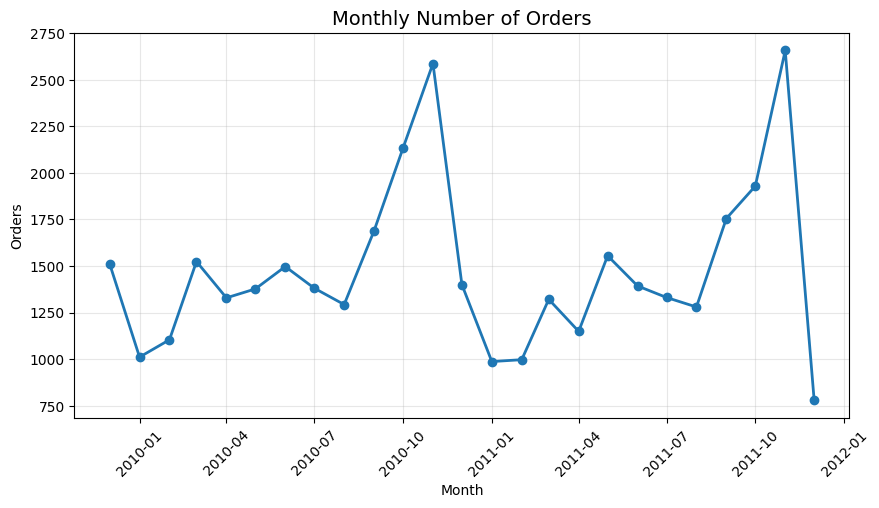

In [23]:
plt.figure(figsize=(10,5))
plt.plot(monthly_revenue["InvoiceStartMonth"], monthly_revenue["orders"], marker = "o", linewidth = "2")
plt.title("Monthly Number of Orders", fontsize=14)
plt.xlabel("Month")
plt.ylabel("Orders")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.show()


### 5.1.3 Monthly Revenue

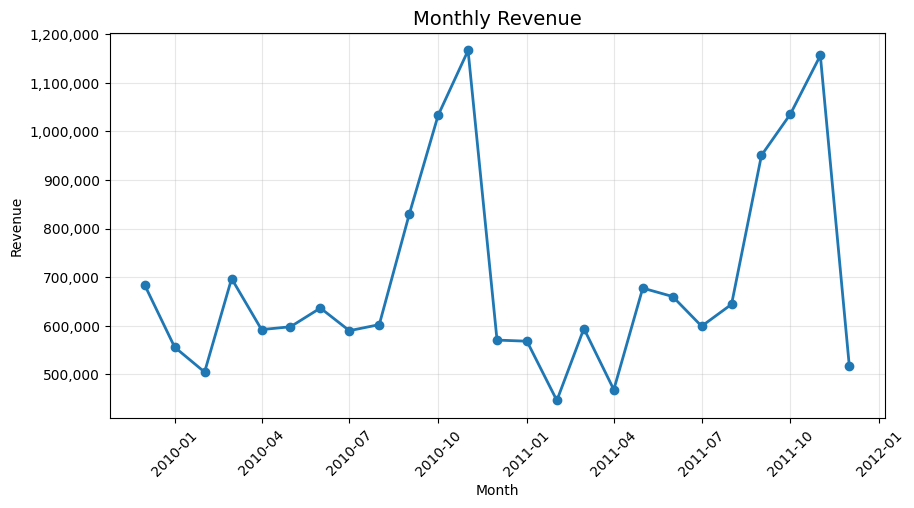

In [24]:
import matplotlib.ticker as mtick

plt.figure(figsize=(10,5))
plt.plot(monthly_revenue["InvoiceStartMonth"], monthly_revenue["revenue"], marker="o", linewidth=2)
plt.title("Monthly Revenue", fontsize=14)
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)

plt.gca().yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))  # 1,234,567
plt.show()


### 5.1.4 AOV (Avarege Order Value)

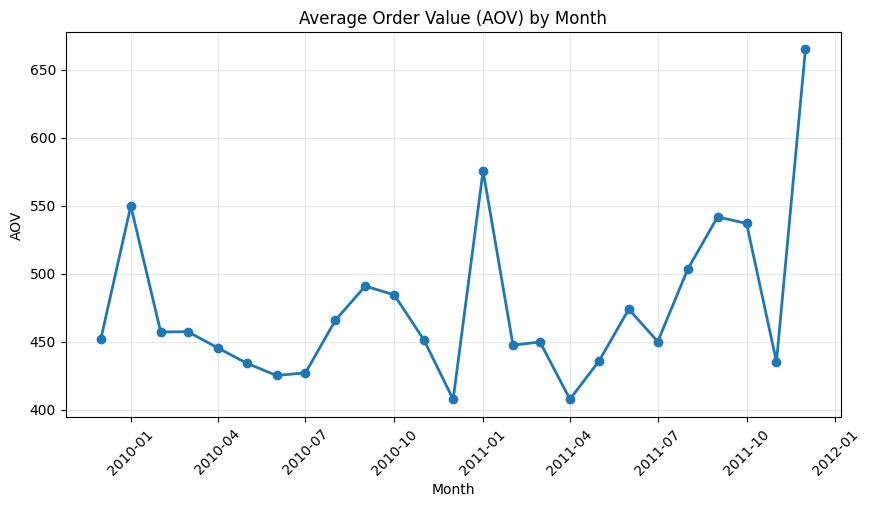

In [25]:
monthly_revenue_plot = monthly_revenue.sort_values("InvoiceStartMonth").copy()
monthly_revenue_plot["AOV"] = monthly_revenue_plot["revenue"] / monthly_revenue_plot["orders"]

plt.figure(figsize=(10,5))
plt.plot(monthly_revenue_plot["InvoiceStartMonth"], monthly_revenue_plot["AOV"], marker="o", linewidth=2)
plt.title("Average Order Value (AOV) by Month")
plt.xlabel("Month")
plt.ylabel("AOV")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.show()

### 5.1.5 Key Insights (General Sales)

- Monthly order volume and revenue fluctuate over time, suggesting changing demand and possible seasonality.
- Average Order Value (AOV) varies across months (roughly ~400–650 range), meaning the average basket size is not constant.
- Because AOV changes, revenue does not always move in perfect sync with order count; some months generate higher revenue mainly due to larger average order values.
- These trends provide a baseline before drilling down into country-level patterns and customer-level behavior (RFM).


## 5.2. Country Analysis

### 5.2.1 Revenue and Orders by Country

In [26]:
pd.options.display.float_format = "{:,.0f}".format

country_revenue = df_clean.groupby("Country").agg(
    orders = ("Invoice", "nunique"),
    revenue = ("TotalPrice", "sum")
).reset_index().sort_values("revenue", ascending = False)

country_revenue.head(7)

,Country,orders,revenue
38,United Kingdom,33541,"14,389,235"
10,EIRE,567,"616,571"
24,Netherlands,228,"554,038"
14,Germany,789,"425,020"
13,France,614,"348,769"
0,Australia,95,"169,283"
32,Spain,154,"108,332"


### 5.2.2 Top 10 Countries by Revenue

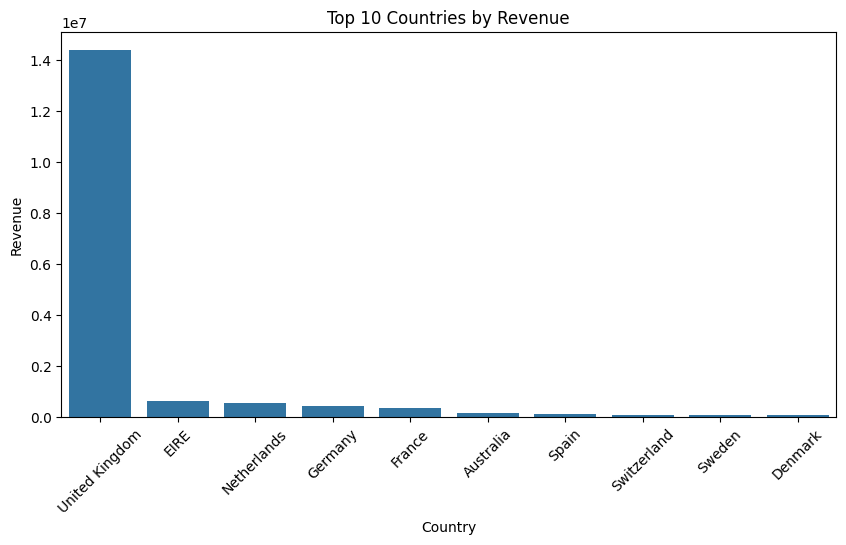

In [27]:
import matplotlib.ticker as ticker

top10 = country_revenue.head(10).reset_index()

plt.figure(figsize = (10,5))
ax = sns.barplot(data=top10, x="Country", y="revenue")
plt.title("Top 10 Countries by Revenue")
plt.ylabel("Revenue")
plt.xlabel("Country")
plt.xticks(rotation = 45)
plt.show()

### 5.2.3 Top Countries by Revenue (Excluding United Kingdom)

In [28]:
country_revenue_no_uk = country_revenue[
    country_revenue["Country"] != "United Kingdom"
]
country_revenue_no_uk.head(10)

,Country,orders,revenue
10,EIRE,567,"616,571"
24,Netherlands,228,"554,038"
14,Germany,789,"425,020"
13,France,614,"348,769"
0,Australia,95,"169,283"
32,Spain,154,"108,332"
34,Switzerland,90,"100,062"
33,Sweden,104,"91,516"
9,Denmark,43,"68,581"
3,Belgium,149,"65,388"


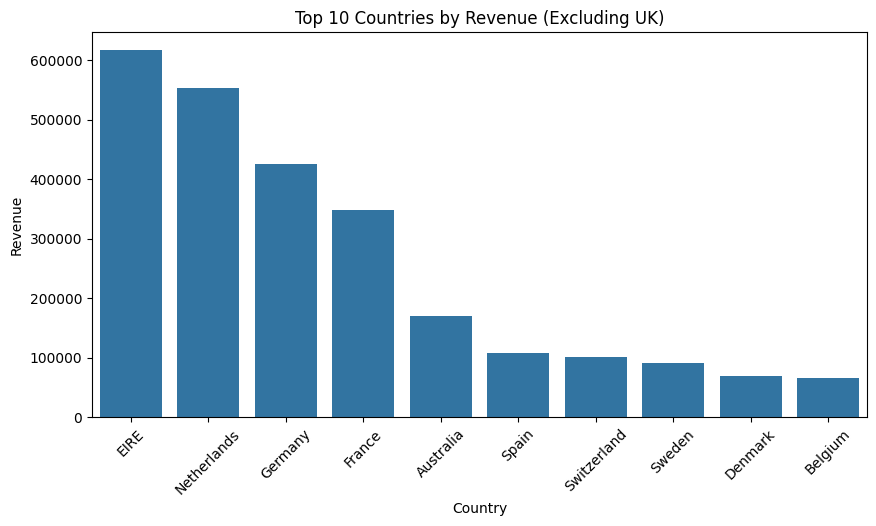

In [29]:
top10_no_uk = country_revenue_no_uk.head(10)

plt.figure(figsize = (10,5))
sns.barplot(data = top10_no_uk, x = "Country", y = "revenue")
plt.title("Top 10 Countries by Revenue (Excluding UK)")
plt.ylabel("Revenue")
plt.xlabel("Country")
plt.xticks(rotation=45)
plt.show()

### 5.2.4 Revenue Share by Country

In [30]:
total_revenue = country_revenue["revenue"].sum()

country_revenue["revenue_share_pct"] = (
    country_revenue["revenue"] / total_revenue * 100
)

country_revenue.assign(
    revenue_share_pct = country_revenue["revenue_share_pct"].map(lambda x: f"{x:.2f}")
).head(10)

,Country,orders,revenue,revenue_share_pct
38,United Kingdom,33541,"14,389,235",82.82
10,EIRE,567,"616,571",3.55
24,Netherlands,228,"554,038",3.19
14,Germany,789,"425,020",2.45
13,France,614,"348,769",2.01
0,Australia,95,"169,283",0.97
32,Spain,154,"108,332",0.62
34,Switzerland,90,"100,062",0.58
33,Sweden,104,"91,516",0.53
9,Denmark,43,"68,581",0.39


### 5.2.5 Key Insights (Country Analysis)

- The United Kingdom dominates total revenue and order volume by a large margin, indicating a strong dependency on the UK market.
- Other countries contribute relatively small portions of total revenue. Even the second and third highest countries are far behind the UK.
- Revenue distribution across countries is highly skewed, with a small number of countries generating most of the sales.
- After excluding the UK, revenue is mainly concentrated in a few European countries such as Ireland (EIRE), Netherlands, Germany, and France.
- International sales exist but are fragmented across multiple markets, suggesting potential growth opportunities outside the UK.
 

## 5.3 Customer Behaviour Analysis

### 5.3.1 Revenue per Customer

In [31]:
revenue_per_customer = df_clean.groupby("Customer ID").agg(
    total_revenue = ("TotalPrice", "sum"),
    total_orders = ("Invoice", "nunique")
).reset_index().sort_values("total_revenue", ascending = False)

revenue_per_customer.head(10)

,Customer ID,total_revenue,total_orders
5692,18102,"580,987",145
2277,14646,"528,603",151
1789,14156,"313,438",156
2538,14911,"291,421",398
5050,17450,"244,784",51
1331,13694,"195,641",143
5109,17511,"172,133",60
4061,16446,"168,472",2
4295,16684,"147,143",55
68,12415,"144,458",28


### 5.3.2 Revenue Distribution per Customer

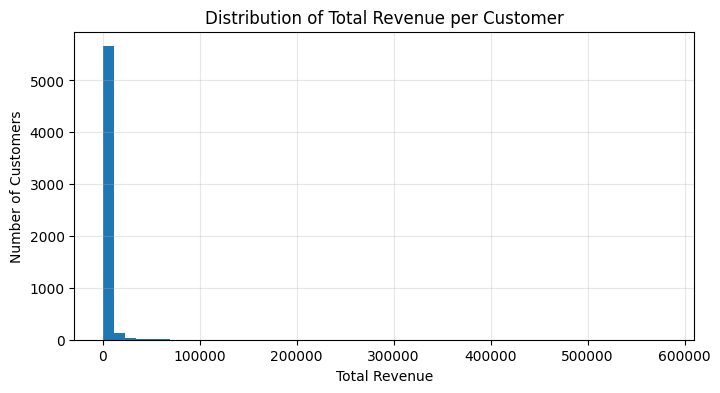

In [32]:
plt.figure(figsize=(8,4))
plt.hist(revenue_per_customer["total_revenue"], bins=50)
plt.title("Distribution of Total Revenue per Customer")
plt.xlabel("Total Revenue")
plt.ylabel("Number of Customers")
plt.grid(alpha=0.3)
plt.show()


### 5.3.3 Orders vs Revenue

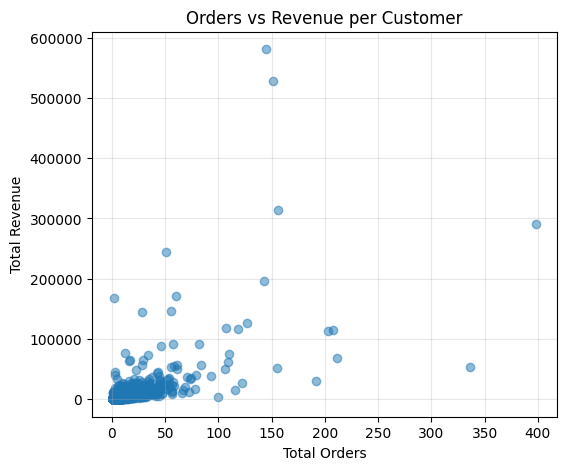

In [33]:
plt.figure(figsize=(6,5))
plt.scatter(
    x = revenue_per_customer["total_orders"],
    y = revenue_per_customer["total_revenue"],
    alpha=0.5
)
plt.xlabel("Total Orders")
plt.ylabel("Total Revenue")
plt.title("Orders vs Revenue per Customer")
plt.grid(alpha=0.3)
plt.show()


### 5.3.4 Key Insights (Customer Behaviour)

- Customer-level analysis shows that revenue is unevenly distributed across customer
- Order count alone is insufficient to measure customer value
- Customer segmentation is necessary to better understand and manange customer behaviour.

# 6. RFM Calculation & Segmentation

- Reference date = last invoice date in the dataset.
- Compute customer-level Recency, Frequency, Monetary metrics.
- Score R/F/M (quartiles) and assign business-friendly segments.


## 6.1 RFM Overview & Reference Date

We use the last invoice date in the dataset as the reference date to measure how recently each customer purchased.

RFM metrics are computed at the customer level:
- **Recency:** days since last purchase  
- **Frequency:** number of unique invoices  
- **Monetary:** total spend (sum of TotalPrice)


## 6.2 Compute RFM Metrics

In [34]:
rfm = df_clean.groupby("Customer ID").agg({
    "InvoiceDate" : lambda x : (reference_date - x.max()).days,
    "Invoice" : "nunique",
    "TotalPrice" : "sum"
})
rfm.head()

,InvoiceDate,Invoice,TotalPrice
Customer ID,,,
12346,325,12,"77,556"
12347,1,8,"4,922"
12348,74,5,"2,019"
12349,18,4,"4,429"
12350,309,1,334


In [35]:
rfm.columns = ["Recency", "Frequency", "Monetary"]
rfm.head()

,Recency,Frequency,Monetary
Customer ID,,,
12346,325,12,"77,556"
12347,1,8,"4,922"
12348,74,5,"2,019"
12349,18,4,"4,429"
12350,309,1,334


## 6.3 Quick Checks

In [36]:
rfm.describe().T

,count,mean,std,min,25%,50%,75%,max
Recency,"5,878",200,209,0,25,95,379,738
Frequency,"5,878",6,13,1,1,3,7,398
Monetary,"5,878","2,956","14,441",3,342,868,"2,248","580,987"


In [37]:
rfm.sort_values("Monetary", ascending=False).head(10)

,Recency,Frequency,Monetary
Customer ID,,,
18102,0,145,"580,987"
14646,1,151,"528,603"
14156,9,156,"313,438"
14911,0,398,"291,421"
17450,7,51,"244,784"
13694,3,143,"195,641"
17511,2,60,"172,133"
16446,0,2,"168,472"
16684,3,55,"147,143"


## 6.4 RFM Distributions

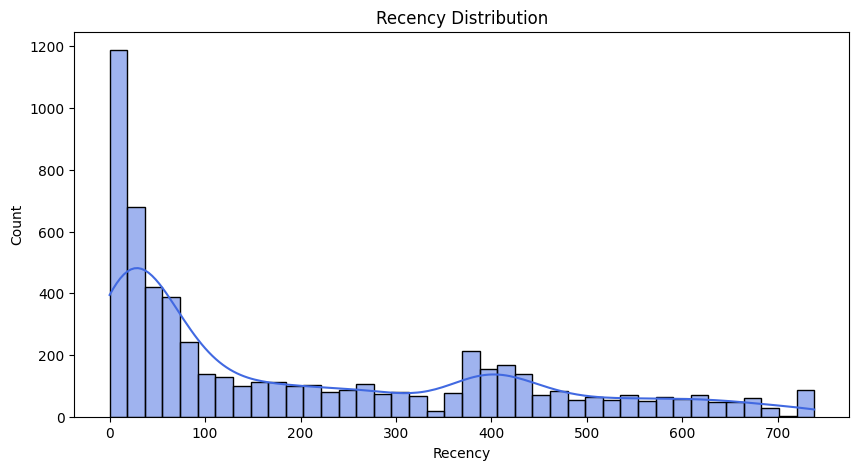

In [38]:
plt.figure(figsize=(10,5))
sns.histplot(rfm["Recency"], bins=40, kde=True, color="royalblue")
plt.title("Recency Distribution")
plt.xlabel("Recency")
plt.ylabel("Count")
plt.show()

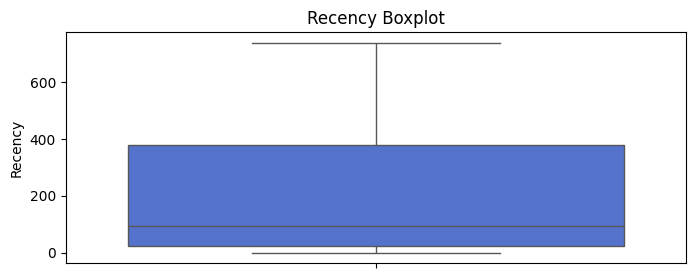

In [39]:
plt.figure(figsize=(8,3))
sns.boxplot(rfm["Recency"], color="royalblue")
plt.title("Recency Boxplot")
plt.show()

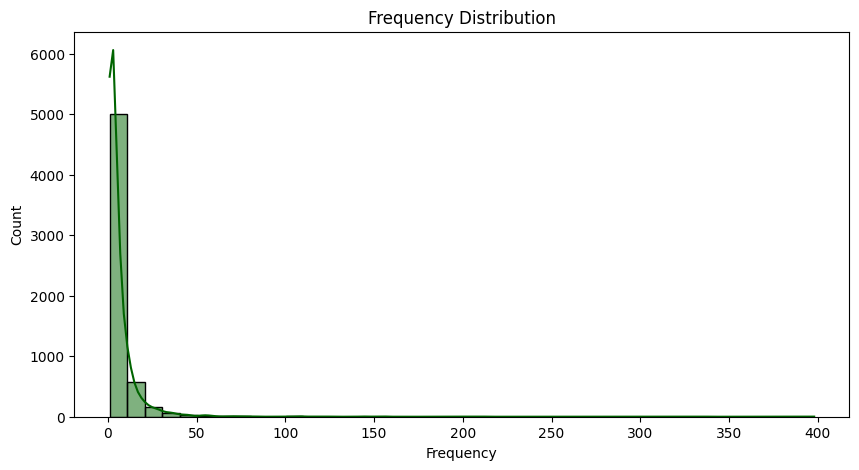

In [40]:
plt.figure(figsize=(10,5))
sns.histplot(rfm["Frequency"], bins=40, kde=True, color="darkgreen")
plt.title("Frequency Distribution")
plt.xlabel("Frequency")
plt.ylabel("Count")
plt.show()

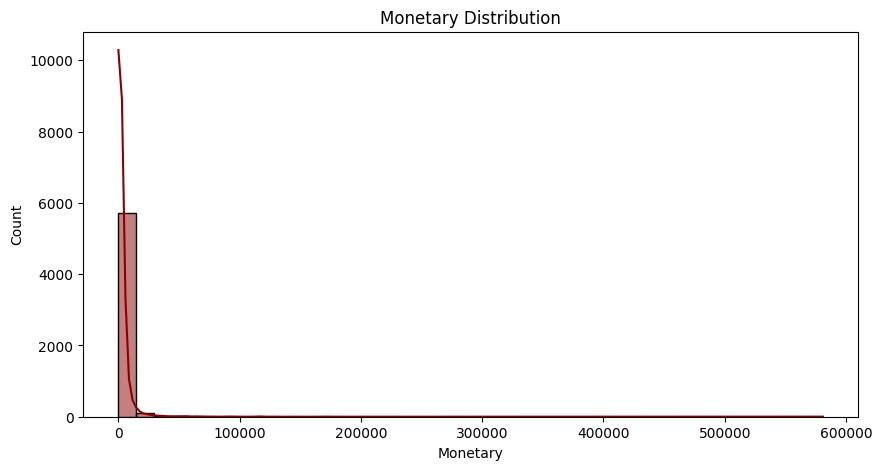

In [41]:
plt.figure(figsize=(10,5))
sns.histplot(rfm["Monetary"], bins=40, kde=True, color="darkred")
plt.title("Monetary Distribution")
plt.xlabel("Monetary")
plt.ylabel("Count")
plt.show()

## 6.5 RFM Scoring (Quartiles)

In [42]:
rfm["R_Score"] = pd.qcut(rfm["Recency"], 4, labels = [4,3,2,1])

In [43]:
rfm["F_Score"] = pd.qcut(rfm["Frequency"].rank(method="first") , 4, labels = [1,2,3,4])

In [44]:
rfm["M_Score"] = pd.qcut(rfm["Monetary"], 4, labels = [1,2,3,4])

In [45]:
rfm["RFM_Score"] = (
    rfm["R_Score"].astype(str) + 
    rfm["F_Score"].astype(str) +
    rfm["M_Score"].astype(str)
)
rfm.head()

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
Customer ID,,,,,,,
12346,325,12,"77,556",2,4,4,244
12347,1,8,"4,922",4,4,4,444
12348,74,5,"2,019",3,3,3,333
12349,18,4,"4,429",4,3,4,434
12350,309,1,334,2,1,1,211


## 6.6 Segment Rules (Business-based)

In [46]:
monetary_80 = rfm['Monetary'].quantile(0.80)
monetary_median = rfm['Monetary'].median()

monetary_80, monetary_median

(2910.0820000000003, 867.74)

In [47]:
def assign_segment(row):
    r = row['Recency']
    f = row['Frequency']
    m = row['Monetary']
    
    # Champions
    if (r < 30) and (f >= 8) and (m >= monetary_80):
        return 'Champions'
    
    # Loyal Customers
    elif (r < 90) and (f >= 4):
        return 'Loyal'
    
    # Potential Loyalists
    elif (r < 60) and (f >= 2) and (f <= 3):
        return 'Potential Loyalists'
    
    # New Customers
    elif (r < 30) and (f == 1):
        return 'New Customers'
    
    # Promising
    elif (30 <= r < 90) and (f == 1):
        return 'Promising'
    
    # At Risk
    elif (180 <= r <= 360) and (f >= 3):
        return 'At Risk'
    
    # About to Sleep
    elif (90 <= r < 180) and (f <= 2):
        return 'About to Sleep'
    
    # Lost
    elif r > 360:
        return 'Lost'
    
    # Others (fallback)
    else:
        return 'Others'


In [48]:
rfm["Segment"] = rfm.apply(assign_segment, axis = 1)
rfm.head()

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Segment
Customer ID,,,,,,,,
12346,325,12,"77,556",2,4,4,244,At Risk
12347,1,8,"4,922",4,4,4,444,Champions
12348,74,5,"2,019",3,3,3,333,Loyal
12349,18,4,"4,429",4,3,4,434,Loyal
12350,309,1,334,2,1,1,211,Others


## 6.7 Segment Summary (Avg R/F/M)

In [49]:
seg_summary = rfm.groupby("Segment").agg(
    customers = ("Segment", "size"),
    recency_avg = ("Recency", "mean"),
    frequency_avg = ("Frequency", "mean"),
    monetary_avg = ("Monetary", "mean")
).round(1).sort_values("monetary_avg", ascending = False)

seg_summary

,customers,recency_avg,frequency_avg,monetary_avg
Segment,,,,
Champions,600,10,26,"15,600"
Loyal,1266,35,8,"2,946"
At Risk,365,254,6,"2,334"
Others,916,180,4,"1,376"
Potential Loyalists,533,25,2,"1,184"
Lost,1627,499,2,797
About to Sleep,206,134,2,518
Promising,236,59,1,418
New Customers,129,16,1,310


## 6.8 Segment Value & Contribution (Revenue Share)

In [50]:
seg_value = rfm.groupby("Segment").agg(
    customers = ("Segment", "size"),
    revenue_total = ("Monetary", "sum"),
    revenue_avg = ("Monetary", "mean")
)

seg_value["customer_share_%"] = (seg_value["customers"] / seg_value["customers"].sum() * 100).round(2)
seg_value["revenue_share_%"] = (seg_value["revenue_total"] / seg_value["revenue_total"].sum() * 100).round(2)

seg_value.sort_values("revenue_total", ascending = False)

,customers,revenue_total,revenue_avg,customer_share_%,revenue_share_%
Segment,,,,,
Champions,600,"9,359,909","15,600",10,54
Loyal,1266,"3,729,294","2,946",22,21
Lost,1627,"1,296,914",797,28,7
Others,916,"1,260,411","1,376",16,7
At Risk,365,"851,862","2,334",6,5
Potential Loyalists,533,"631,112","1,184",9,4
About to Sleep,206,"106,702",518,4,1
Promising,236,"98,571",418,4,1
New Customers,129,"40,031",310,2,0


## 6.9 Segment Visuals

### 6.9.0 Helper: Annotate bar values

In [51]:
# function of print values on the bar
def print_values_on_bar(ax):
    for p in ax.patches:
        ax.annotate(
            f"{int(p.get_height())}",
            (p.get_x() + p.get_width()/2, p.get_height()),
            ha = "center", va = "bottom", fontsize = 9
        )

### 6.9.1 Segment Size (Number of Customers)

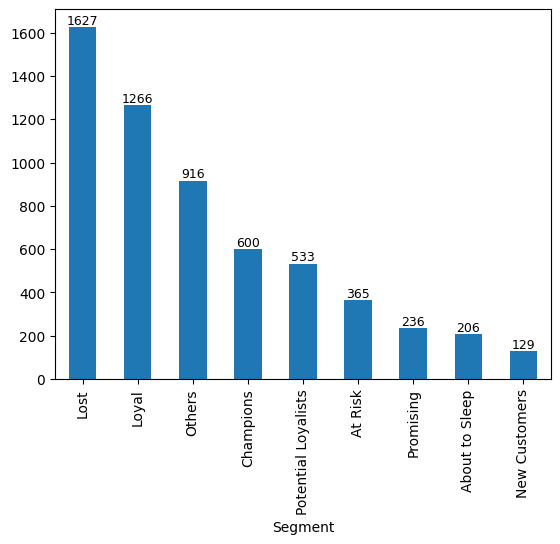

In [52]:
ax = rfm['Segment'].value_counts().plot(kind = "bar")
print_values_on_bar(ax)

### 6.9.2 Revenue Share by Segment

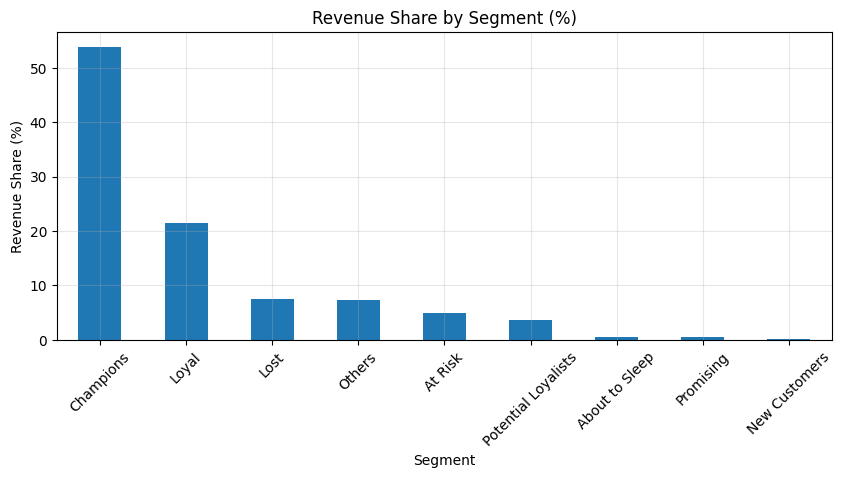

In [53]:
plt.figure(figsize=(10,4))
seg_value.sort_values("revenue_share_%", ascending=False)["revenue_share_%"].plot(kind="bar")
plt.title("Revenue Share by Segment (%)")
plt.xlabel("Segment")
plt.ylabel("Revenue Share (%)")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.show()

### 6.9.3 Average Monetary Value by Segment

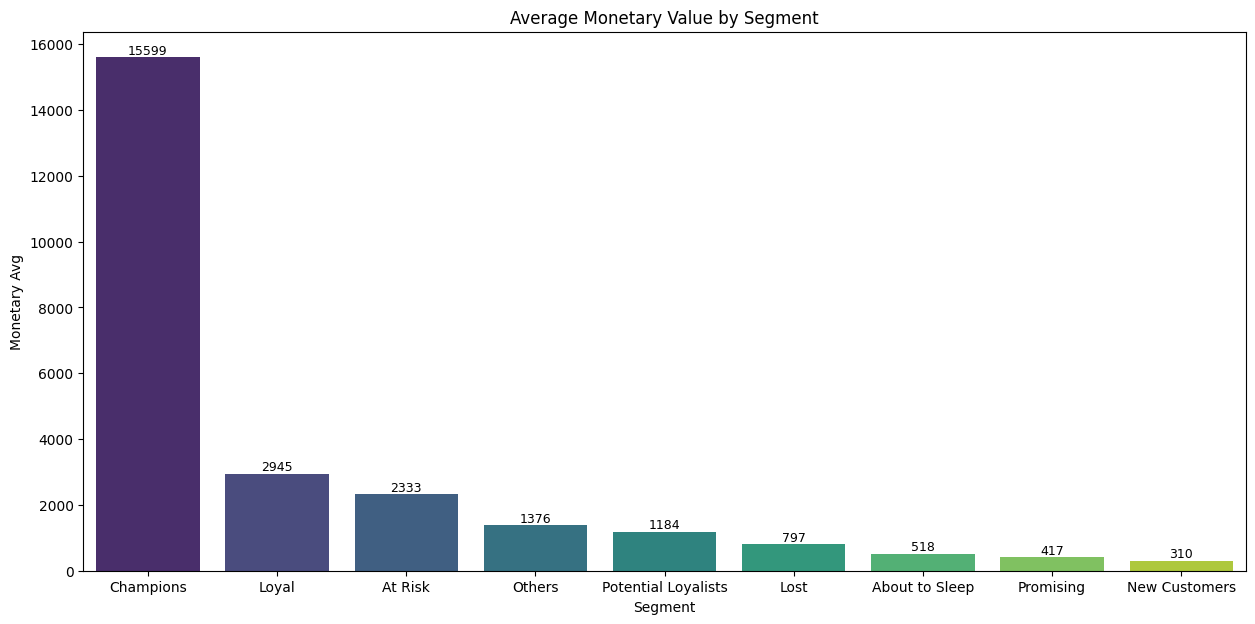

In [54]:
plt.figure(figsize=(15,7))
ax = sns.barplot(
    data = seg_summary.reset_index(),
    x = "Segment",
    y = "monetary_avg",
    palette = "viridis"
)

print_values_on_bar(ax)

plt.title("Average Monetary Value by Segment")
plt.xlabel("Segment")
plt.ylabel("Monetary Avg")
plt.show()

### 6.9.4 Monetary Distribution by Segment (Capped at 99th Percentile)

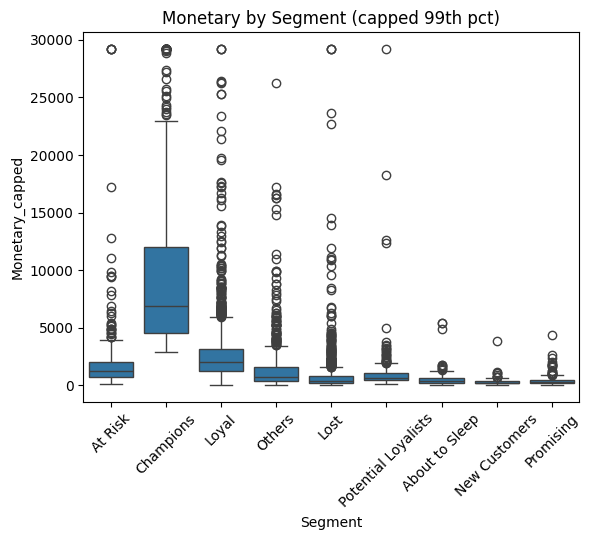

In [55]:
p99 = rfm['Monetary'].quantile(0.99)
tmp = rfm.assign(Monetary_capped = rfm['Monetary'].clip(upper=p99))

sns.boxplot(data=tmp.reset_index(), x='Segment', y='Monetary_capped')
plt.xticks(rotation=45)
plt.title('Monetary by Segment (capped 99th pct)')
plt.show()

## 6.10 Key Insights (RFM)

- Champions generate a disproportionate share of revenue despite being a smaller customer group.
- Lost is the largest segment by customer count with very high recency, indicating many inactive customers.
- Loyal and Potential Loyalists are promising targets for retention and upsell strategies.
